In [3]:
import networkx as nx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [4]:
N = 60 #no. of nodes
p = 0.05 #ocu
G = nx.erdos_renyi_graph(N, p)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}

In [5]:
from bp_error.perc_func import perc_message_passing
from bp_error.perc_func import initialize_messages

In [ ]:

connections = {}
node_weights = {}
p_values = []
cluster_values = []

diff_check = 1

for p in range(10, 0, -1):
    connections = initialize_messages(connections, A, N)
    s_values = []
    p_values.append(p)
    diff_check = 1
    while diff_check > 0.00000000001:

        for key, values in connections.items():
            row, col = key.split(', ')
            failure = jnp.array([0, 0])
            failure = perc_message_passing(connections, A, int(row), int(col), p/10, N)
            diff_check = max(abs(connections[f'{col}, {row}']- float(failure[0])), abs(connections[f'{row}, {col}']- float(failure[1])))
            connections[f'{col}, {row}'] = float(failure[0]) #mu_(j -> i)
            connections[f'{row}, {col}'] = float(failure[1]) #mu_(i -> j)

    for i in range(0, N):
        temp = 1
        for j in range(0, N):
            if A[i][j] == 1: #obtaining my mu_i
                temp = temp * connections[f'{i}, {j}']
        #calculating s_i
        node_weights[f'{i}'] = 1 - temp
        s_values.append(node_weights[f'{i}'])
    cluster_values.append((1/N)*sum(s_values))

node_colors = [node_weights[str(n)] for n in G.nodes()]
print(p_values)
print(cluster_values)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
[0.0005241871744757765, 0.012620118691105797, 0.040754054695619435, 0.10792047119223669, 0.2860621812052492, 0.7186285334179678, 0.9075090519949995, 0.9393503327492603, 0.9503444187549273, 0.9555264282428458]


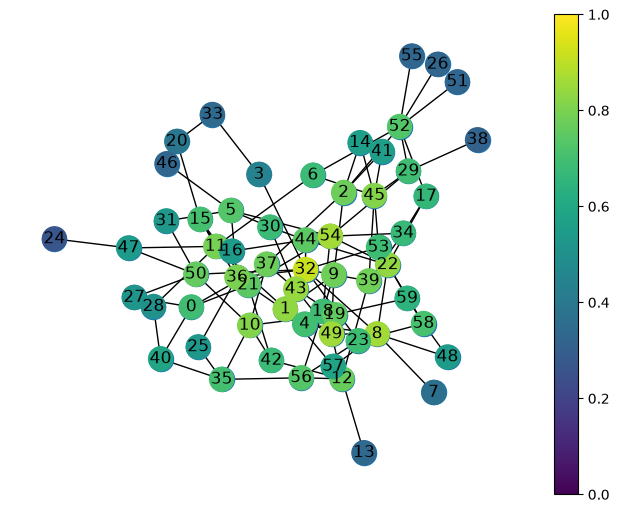

In [132]:
nx.draw(G, pos)
nx.draw_networkx_labels(G, pos, labels)
image = nx.draw_networkx_nodes(G, pos, node_color=node_colors, vmin=0, vmax=1)
plt.colorbar(image)

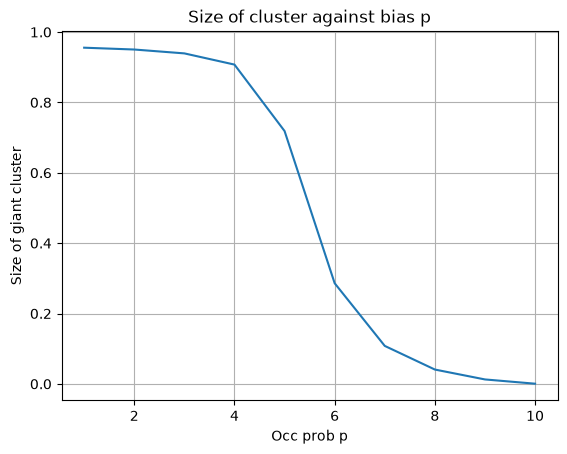

In [ ]:
plt.plot(p_values/10, cluster_values)
plt.xlabel("Occ prob p")
plt.ylabel("Size of giant cluster")
plt.title("Size of cluster against bias p")
plt.grid()

plt.show()